<img src="./assets/ga-logo.png" style="float: left; margin: 20px; height: 55px">

# Lab: Simple Linear Regression with Sacramento Real Estate Data

---

In this lab you will hone your exploratory data analysis (EDA) skills and practice constructing linear regressions on a data set of Sacramento real estate sales.  The data set contains information on qualities of the property, location of the property, and time of sale.

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

### 1. Read in the Sacramento housing data set.

The file is stored in the `data` subfolder.

In [5]:
housing = pd.read_csv('./data/sacramento_real_estate_transactions.csv')
housing.head()


,street,city,zip,state,beds,baths,sq__ft,type,sale_date,price,latitude,longitude
0,3526 HIGH ST,SACRAMENTO,95838,CA,2,1,836,Residential,Wed May 21 00:00:00 EDT 2008,59222,38.631913,-121.434879
1,51 OMAHA CT,SACRAMENTO,95823,CA,3,1,1167,Residential,Wed May 21 00:00:00 EDT 2008,68212,38.478902,-121.431028
2,2796 BRANCH ST,SACRAMENTO,95815,CA,2,1,796,Residential,Wed May 21 00:00:00 EDT 2008,68880,38.618305,-121.443839
3,2805 JANETTE WAY,SACRAMENTO,95815,CA,2,1,852,Residential,Wed May 21 00:00:00 EDT 2008,69307,38.616835,-121.439146
4,6001 MCMAHON DR,SACRAMENTO,95824,CA,2,1,797,Residential,Wed May 21 00:00:00 EDT 2008,81900,38.519470,-121.435768


### 2. Conduct exploratory data analysis on this data set. 

If you discover any issues with the data, fix them to the best of your ability. Report any notable findings.

__Note:__
- Assign the correct data type to each column.
- Look for missing values and determine how to handle them. Keep in mind that most machine learning models cannot process null values.
- Check the value ranges for numerical and categorical columns to identify any anomalies.
- Examine the distribution of values and investigate potential outliers.

(985, 12)
<class 'pandas.DataFrame'>
RangeIndex: 985 entries, 0 to 984
Data columns (total 12 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   street     985 non-null    str    
 1   city       985 non-null    str    
 2   zip        985 non-null    int64  
 3   state      985 non-null    str    
 4   beds       985 non-null    int64  
 5   baths      985 non-null    int64  
 6   sq__ft     985 non-null    int64  
 7   type       985 non-null    str    
 8   sale_date  985 non-null    str    
 9   price      985 non-null    int64  
 10  latitude   985 non-null    float64
 11  longitude  985 non-null    float64
dtypes: float64(2), int64(5), str(5)
memory usage: 156.9 KB
type
Residential     917
Condo            54
Multi-Family     13
Unkown            1
Name: count, dtype: int64
state
CA    984
AC      1
Name: count, dtype: int64
39 unique cities
Duplicate rows: 3
             beds       baths       sq__ft          price    latitude  \
count

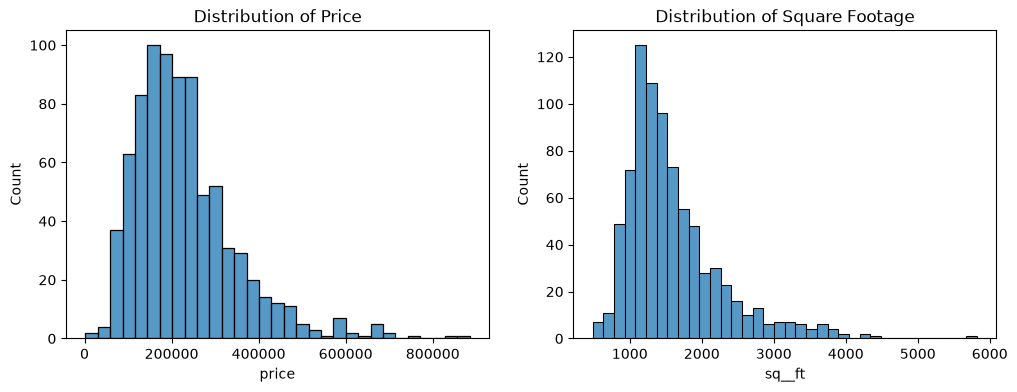

                    street         city  beds  baths  sq__ft   price
701         14151 INDIO DR  SLOUGHHOUSE   3.0    4.0  5822.0    2000
700   9401 BARREL RACER CT       WILTON   4.0    3.0  4400.0  884790
472  5201 BLOSSOM RANCH DR    ELK GROVE   4.0    4.0  4303.0  450000


In [6]:
# check info 
print(housing.shape)
housing.info()

# Check categorical columns 
print(housing['type'].value_counts())
print(housing['state'].value_counts())
print(housing['city'].nunique(), 'unique cities')

# Check for exact duplicate rows 
print('Duplicate rows:', housing.duplicated().sum())
housing = housing.drop_duplicates()

#Check numeric ranges 
print(housing[['beds', 'baths', 'sq__ft', 'price', 'latitude', 'longitude']].describe())

# Sacramento-area latitude should be roughly 38-39. This row has a latitude of -121 and a negative price the whole row is corrupted not just one field.
print(housing[(housing['latitude'] < 30) | (housing['price'] < 0)])
housing = housing[housing['price'] > 0]

# 'type' has a typo
housing['type'] = housing['type'].replace('Unkown', 'Unknown')

# beds/baths/sq__ft of exactly 0 isn't realistic for a home that actually
# sold these are missing values encoded as 0, not true zeros
for col in ['beds', 'baths', 'sq__ft']:
    print(col, 'zeros:', (housing[col] == 0).sum())
    housing[col] = housing[col].replace(0, np.nan)

print(housing.isnull().sum())

# analysis  drop rows missing beds/baths/sq__ft instead of imputing
housing = housing.dropna(subset=['beds', 'baths', 'sq__ft'])

# sale_date is a string with a timezone abbreviation pandas can't parse
housing['sale_date'] = housing['sale_date'].str.replace(' EDT', '', regex=False)
housing['sale_date'] = pd.to_datetime(housing['sale_date'], format='%a %b %d %H:%M:%S %Y')
print(housing['sale_date'].min(), 'to', housing['sale_date'].max())

# state is 'CA' for every remaining row
print(housing['state'].unique())
housing = housing.drop(columns=['state'])

# zip is a category label, not a continuous number 
housing['zip'] = housing['zip'].astype('category')

housing = housing.reset_index(drop=True)
print('final shape:', housing.shape)

# --- Distribution / outlier check ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(housing['price'], ax=axes[0])
axes[0].set_title('Distribution of Price')
sns.histplot(housing['sq__ft'], ax=axes[1])
axes[1].set_title('Distribution of Square Footage')
plt.show()

print(housing.nlargest(3, 'sq__ft')[['street', 'city', 'beds', 'baths', 'sq__ft', 'price']])



When you've finished cleaning or have made a good deal of progress cleaning, it's always a good idea to save your work. Use the pandas `to_csv` method to export your cleaned dataset.

```python
# example -- your dataframe name may be different
dataframe.to_csv('./datasets/sacramento_cleaned_dataframe.csv', index=False)

```

In [8]:
housing.to_csv('./data/sacramento_cleaned_dataframe.csv', index=False)

### 3. Our goal will be to predict price. List variables that you think qualify as predictors of price in an SLR model.

For each of the variables you believe should be considered, generate a plot showing the relationship between the independent and dependent variables.

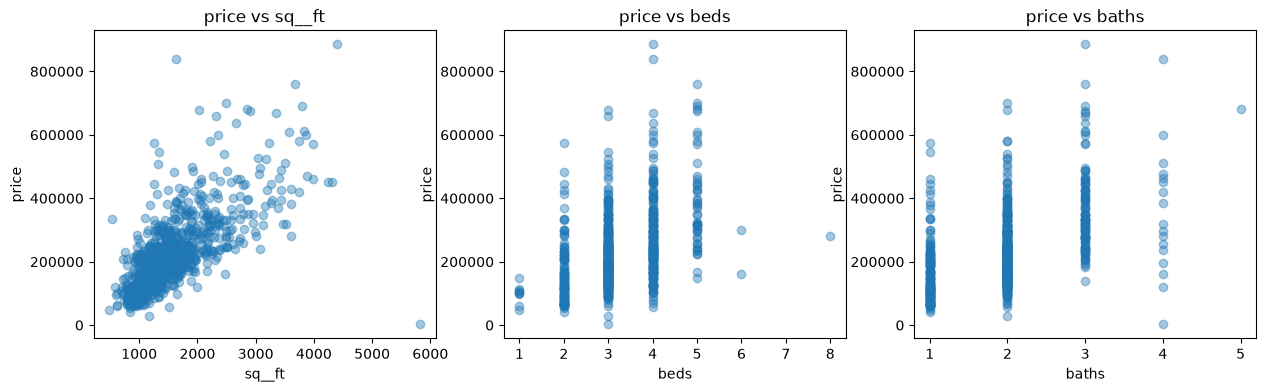

In [9]:

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ['sq__ft', 'beds', 'baths']):
    ax.scatter(housing[col], housing['price'], alpha=0.4)
    ax.set_xlabel(col)
    ax.set_ylabel('price')
    ax.set_title(f'price vs {col}')
plt.show()

### 4. Which variable would be the best predictor of Y in an SLR model? Why?

In [10]:
corrs = housing[['beds', 'baths', 'sq__ft', 'price']].corr()['price'].sort_values(ascending=False)
print(corrs)

price     1.000000
sq__ft    0.693247
baths     0.501123
beds      0.442892
Name: price, dtype: float64


### 5. Write a function that will take in two lists, `x` and `y`, and return the intercept and slope coefficients that minimize SSE. 

`y` is the target variable, and `x` is the predictor variable.

**Don't use `scikit-learn` for this**. Instead, use `numpy`.

The slope and intercept of simple linear regression can be calculated by using certain summary statistics. In particular, we'll need to know:

- $\bar{x}$, the mean of `x`
- $\bar{y}$, the mean of `y`
- $s_{x}$, the standard deviation of `x`
- $s_{y}$, the standard deviation of `y`
- $r_{xy}$, the correlation of `x` and `y`

Given these summary statistics, the **coefficient on `X`** (or the slope) can be given by $\beta_{1} = r_{xy} * \frac{s_{y}}{s_{x}}$. The **intercept of the model** can be given by $\beta_{0} = \bar{y} - \beta_{1}\bar{x}$.

Your function should take in `x` and `y`, then use the above summary statistics to calculate the slope and intercept.

- **Test your function on price and the variable you determined was the best predictor in Problem 4.**
- **Report the slope and intercept.**

In [11]:
def slr(x, y):
    x = np.array(x, dtype=float)
    y = np.array(y, dtype=float)
    r_xy = np.corrcoef(x, y)[0, 1]
    slope = r_xy * (y.std() / x.std())
    intercept = y.mean() - slope * x.mean()
    return intercept, slope

intercept, slope = slr(housing['sq__ft'], housing['price'])
print('Intercept:', intercept)
print('Slope:', slope)

lr_check = LinearRegression()
lr_check.fit(housing[['sq__ft']], housing['price'])
print('sklearn intercept:', lr_check.intercept_, 'sklearn slope:', lr_check.coef_[0])


Intercept: 30352.243076665123
Slope: 125.15261406074985
sklearn intercept: 30352.243076665123 sklearn slope: 125.15261406074985


### 6. Interpret the intercept and the slope.

In [ ]:
print(f"Intercept: ${intercept:,.0f}")
print(f"Slope: ${slope:,.2f} ")


Intercept: $30,352
Slope: $125.15 


### 7. Give an example of how this model could be used for prediction and how it could be used for inference. 

**Be sure to make it clear which example is associated with prediction and which is associated with inference.**

In [15]:
example_sqft = 1800
predicted_price = intercept + slope * example_sqft
predicted_price

np.float64(255626.94838601488)

### 8: [Bonus] Using the model you came up with in Problem 5, calculate and plot the residuals.

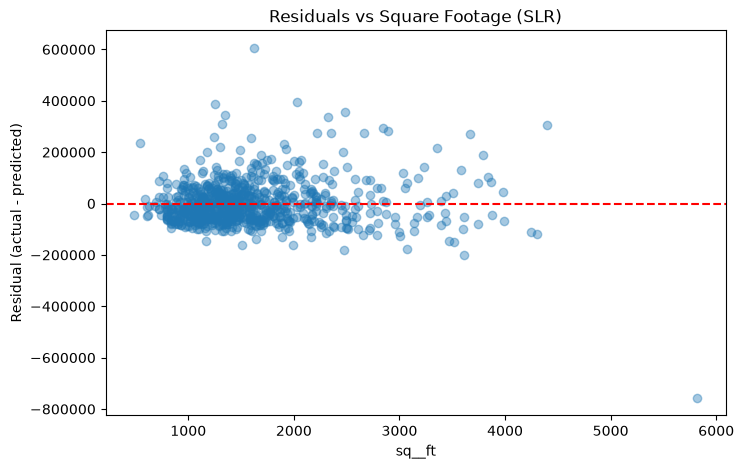

In [24]:
housing['y_pred_slr'] = intercept + slope * housing['sq__ft']
housing['residual_slr'] = housing['price'] - housing['y_pred_slr']

plt.figure(figsize=(8, 5))
plt.scatter(housing['sq__ft'], housing['residual_slr'], alpha=0.4)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('sq__ft')
plt.ylabel('Residual (actual - predicted)')
plt.title('Residuals vs Square Footage (SLR)')
plt.show()


---

## Dummy Variables

It is important to be cautious with categorical variables, which represent distict groups or categories, when building a regression. If put in a regression "as-is," categorical variables represented as integers will be treated like *continuous* variables.

That is to say, instead of group "3" having a different effect on the estimation than group "1" it will estimate literally 3 times more than group 1. 

For example, if occupation category "1" represents "analyst" and occupation category "3" represents "barista", and our target variable is salary, if we leave this as a column of integers then barista will always have `beta*3` the effect of analyst.

This will almost certainly force the beta coefficient to be something strange and incorrect. Instead, we can re-represent the categories as multiple "dummy coded" columns.



#### A Word of Caution When Creating Dummies

Let's touch on precautions we should take when dummy coding.

**If you convert a qualitative variable to dummy variables, you want to turn a variable with N categories into N-1 variables.**

> **Scenario 1:** Suppose we're working with the variable "sex" or "gender" with values "M" and "F". 

You should include in your model only one variable for "sex = F" which takes on 1 if sex is female and 0 if sex is not female! Rather than saying "a one unit change in X," the coefficient associated with "sex = F" is interpreted as the average change in Y when sex = F relative to when sex = M.

| Female | Male | 
|-------|------|
| 0 | 1 | 
| 1 | 0 |
| 0 | 1 |
| 1 | 0 |
| 1 | 0 |
_As we can see a 1 in the female column indicates a 0 in the male column. And so, we have two columns stating the same information in different ways._

> Scenario 2: Suppose we're modeling revenue at a bar for each of the days of the week. We have a column with strings identifying which day of the week this observation occured in.

We might include six of the days as their own variables: "Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday". **But not all 7 days.**  

|Monday | Tuesday | Wednesday | Thursday | Friday | Saturday | 
|-------|---------|-----------|----------|--------|----------|
| 1     | 0       |0          |      0   |0       | 0        | 
| 0     | 1       |0          |      0   |0       | 0        | 
| 0     | 0       |1          |      0   |0       | 0        | 
| 0     | 0       |0          |      1   |0       | 0        | 
| 0     | 0       |0          |      0   |1       | 0        | 
| 0     | 0       |0          |      0   |0       | 1        | 
| 0     | 0       |0          |      0   |0       | 0        | 

_As humans we can infer from the last row that if its is not Monday, Tuesday, Wednesday, Thursday, Friday or Saturday, it must be Sunday. Models work the same way._

The coefficient for Monday is then interpreted as the average change in revenue when "day = Monday" relative to "day = Sunday." The coefficient for Tuesday is interpreted as the average change in revenue when "day = Tuesday" relative to "day = Sunday" and so on.

The category you leave out, which the other columns are *relative to*, is often referred to as the **reference category**.

### 9. Use the `pd.get_dummies` function to convert the `type` column into dummy-coded variables.

In [25]:
type_dummies = pd.get_dummies(housing['type'], prefix='type', drop_first=True)
housing = pd.concat([housing, type_dummies], axis=1)
housing.head()


,street,city,zip,beds,baths,sq__ft,type,sale_date,price,latitude,longitude,y_pred_slr,residual_slr,type_Multi-Family,type_Residential
0,3526 HIGH ST,SACRAMENTO,95838,2.0,1.0,836.0,Residential,2008-05-21,59222,38.631913,-121.434879,134979.828431,-75757.828431,False,True
1,51 OMAHA CT,SACRAMENTO,95823,3.0,1.0,1167.0,Residential,2008-05-21,68212,38.478902,-121.431028,176405.343686,-108193.343686,False,True
2,2796 BRANCH ST,SACRAMENTO,95815,2.0,1.0,796.0,Residential,2008-05-21,68880,38.618305,-121.443839,129973.723869,-61093.723869,False,True
3,2805 JANETTE WAY,SACRAMENTO,95815,2.0,1.0,852.0,Residential,2008-05-21,69307,38.616835,-121.439146,136982.270256,-67675.270256,False,True
4,6001 MCMAHON DR,SACRAMENTO,95824,2.0,1.0,797.0,Residential,2008-05-21,81900,38.519470,-121.435768,130098.876483,-48198.876483,False,True


### 10. Check the dummy columns you've created. Do they all make sense?

Use `.head()` on the new dataframe you've created. Depending on how you cleaned the data earlier in this notebook, there may be a dummy column that needs to be removed. Check that all the columns you've created make sense, and if any of the columns seem to be errors, drop them. If there don't appear to be any errors, then move on to the next step!

In [26]:
print(housing['type'].value_counts())
housing[['type'] + list(type_dummies.columns)].head()

type
Residential     757
Condo            41
Multi-Family     13
Name: count, dtype: int64


,type,type_Multi-Family,type_Residential
0,Residential,False,True
1,Residential,False,True
2,Residential,False,True
3,Residential,False,True
4,Residential,False,True


### 11. Build what you think may be the best MLR model predicting `price`. 

Choose at least three variables, and build a model that uses them to predict price. At least one of the variables you choose should be a dummy-coded variable. (This can be one we created before or a new one.) 

You may need to load in the scikit-learn API:

```python
from sklearn.linear_model import LinearRegression

model = LinearRegression()
```

In [27]:
features = ['sq__ft', 'beds', 'baths', 'type_Multi-Family', 'type_Residential']
X = housing[features]
y = housing['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

mlr = LinearRegression()
mlr.fit(X_train, y_train)

print(dict(zip(features, mlr.coef_)))
print('Intercept:', mlr.intercept_)


{'sq__ft': np.float64(124.9776036805377), 'beds': np.float64(-15058.691751551203), 'baths': np.float64(16684.107213102296), 'type_Multi-Family': np.float64(-24637.99064689355), 'type_Residential': np.float64(31198.075860626202)}
Intercept: 20229.61744697034


### 12. Plot the true price vs the predicted price to evaluate your MLR visually.

You can use matplotlib or seaborn.

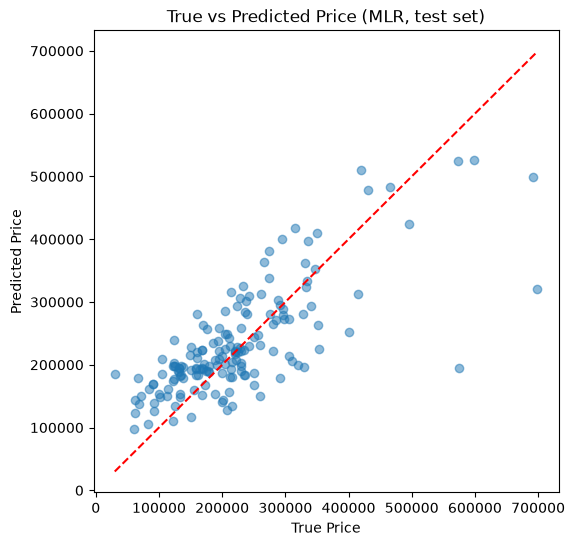

In [28]:
y_pred_test = mlr.predict(X_test)

plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred_test, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('True Price')
plt.ylabel('Predicted Price')
plt.title('True vs Predicted Price (MLR, test set)')
plt.show()


### 13. List the five assumptions for an MLR model. 

Indicate which ones are the same as the assumptions for an SLR model. 

### 14. Pick at least two assumptions and explain whether or not you believe them to be met for your model, and explain why.

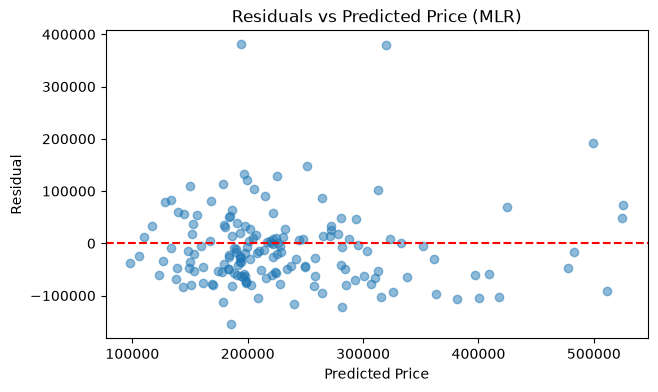

                     sq__ft      beds     baths  type_Multi-Family  \
sq__ft             1.000000  0.688330  0.719433           0.061922   
beds               0.688330  1.000000  0.653772           0.138478   
baths              0.719433  0.653772  1.000000           0.130392   
type_Multi-Family  0.061922  0.138478  0.130392           1.000000   
type_Residential   0.160953  0.252315  0.100082          -0.445158   

                   type_Residential  
sq__ft                     0.160953  
beds                       0.252315  
baths                      0.100082  
type_Multi-Family         -0.445158  
type_Residential           1.000000  


In [29]:
residuals = y_test - y_pred_test
plt.figure(figsize=(7, 4))
plt.scatter(y_pred_test, residuals, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted Price')
plt.ylabel('Residual')
plt.title('Residuals vs Predicted Price (MLR)')
plt.show()

print(X_train.corr())

### 15. Regression Metrics

Implement a function called `r2_adj()` that will calculate $R^2_{adj}$ for a model.

The adjusted R-squared is calculated as $R^2_{adj} = 1 - \left[ \frac{(1 - R^2)(n - 1)}{n - k - 1} \right]$.

Unlike standard R-squared, which always increases when you add new variables, Adjusted R-squared will actually decrease if you add a useless variable to your model. This helps you find the simplest and most effective model.
- $R^2$: The standard R-squared value (coefficient of determination)
- $n$: The total number of observations (sample size)
- $k$: The number of independent variables (predictors) in your model

### 17. Metrics, metrics, everywhere...

Calculate and interpret at least three regression metrics. How well does your model perform?

In [30]:
def r2_adj(r2, n, k):
    '''Adjusted R^2: penalizes adding predictors that don't earn their keep.'''
    return 1 - (((1 - r2) * (n - 1)) / (n - k - 1))

r2 = r2_score(y_test, y_pred_test)
rmse = mean_squared_error(y_test, y_pred_test) ** 0.5
mae = mean_absolute_error(y_test, y_pred_test)
adj_r2 = r2_adj(r2, n=X_test.shape[0], k=X_test.shape[1])

print(f'R2: {r2:.3f}')
print(f'Adjusted R2: {adj_r2:.3f}')
print(f'RMSE: ${rmse:,.0f}')
print(f'MAE: ${mae:,.0f}')

R2: 0.553
Adjusted R2: 0.538
RMSE: $74,564
MAE: $54,346


### 18. Model Iteration

Adjust your model by adding or removing a variable. Then calculate the same regression metrics as you used in question 17. Has your model performance increased or decreased?

**Guidance:**
1. Look at the correlation between the dependent and independent variables. Which two predictors are the most correlated with each other?
2. Drop the one you think is less useful and refit the model with the remaining features.
3. Compare the new R2 and RMSE to your original model from Q11/Q17.


In [31]:
print(X_train.corr())


features_v2 = ['sq__ft', 'baths', 'type_Multi-Family', 'type_Residential']
X2 = housing[features_v2]
X_train2, X_test2, y_train2, y_test2 = train_test_split(X2, y, test_size=0.2, random_state=42)

mlr2 = LinearRegression()
mlr2.fit(X_train2, y_train2)
y_pred_test2 = mlr2.predict(X_test2)

r2_2 = r2_score(y_test2, y_pred_test2)
rmse_2 = mean_squared_error(y_test2, y_pred_test2) ** 0.5

print(f'New R2: {r2_2:.3f} (was {r2:.3f})')
print(f'New RMSE: ${rmse_2:,.0f} (was ${rmse:,.0f})')



                     sq__ft      beds     baths  type_Multi-Family  \
sq__ft             1.000000  0.688330  0.719433           0.061922   
beds               0.688330  1.000000  0.653772           0.138478   
baths              0.719433  0.653772  1.000000           0.130392   
type_Multi-Family  0.061922  0.138478  0.130392           1.000000   
type_Residential   0.160953  0.252315  0.100082          -0.445158   

                   type_Residential  
sq__ft                     0.160953  
beds                       0.252315  
baths                      0.100082  
type_Multi-Family         -0.445158  
type_Residential           1.000000  
New R2: 0.551 (was 0.553)
New RMSE: $74,723 (was $74,564)


### 19. Add `city` as a feature

Use `OneHotEncoder` on the `city` column to add location as a feature. Since some cities only have 1-2 sales, group cities with fewer than 20 sales into `'Other'` first. Compare R2 and RMSE to the base model.

In [32]:
city_counts = housing['city'].value_counts()
rare_cities = city_counts[city_counts < 20].index
housing['city_grouped'] = housing['city'].where(~housing['city'].isin(rare_cities), 'Other')
print(housing['city_grouped'].value_counts())

ohe = OneHotEncoder(drop='first', sparse_output=False)
city_encoded = ohe.fit_transform(housing[['city_grouped']])
city_encoded_df = pd.DataFrame(
    city_encoded,
    columns=ohe.get_feature_names_out(['city_grouped']),
    index=housing.index
)
housing_with_city = pd.concat([housing, city_encoded_df], axis=1)

features_city = features_v2 + list(city_encoded_df.columns)
X3 = housing_with_city[features_city]
X_train3, X_test3, y_train3, y_test3 = train_test_split(X3, y, test_size=0.2, random_state=42)

mlr3 = LinearRegression()
mlr3.fit(X_train3, y_train3)
y_pred_test3 = mlr3.predict(X_test3)

r2_3 = r2_score(y_test3, y_pred_test3)
rmse_3 = mean_squared_error(y_test3, y_pred_test3) ** 0.5
print(f'With city  -> R2: {r2_3:.3f}  RMSE: ${rmse_3:,.0f}')
print(f'Without city -> R2: {r2_2:.3f}  RMSE: ${rmse_2:,.0f}')


city_grouped
SACRAMENTO         422
ELK GROVE          107
Other              105
CITRUS HEIGHTS      34
ANTELOPE            33
ROSEVILLE           28
RANCHO CORDOVA      21
NORTH HIGHLANDS     21
GALT                20
CARMICHAEL          20
Name: count, dtype: int64
With city  -> R2: 0.574  RMSE: $72,770
Without city -> R2: 0.551  RMSE: $74,723


## Part 2: Sacramento Real Estate Deep Dive & Model Diagnostics

---

### 21. Beating the Baseline
A machine learning model is only useful if it performs better than a "naive guess". Create a baseline model:

Calculate the mean `price` of your training data to get the "Baseline" prediction, then, report how much money "on average" does your MLR model save us in pricing errors compared to just guessing using the average?

In [33]:
baseline_pred = y_train3.mean()
baseline_rmse = mean_squared_error(y_test3, [baseline_pred] * len(y_test3)) ** 0.5

print(f'Baseline (always guess the mean) RMSE: ${baseline_rmse:,.0f}')
print(f'MLR model RMSE: ${rmse_3:,.0f}')
print(f'Average savings per prediction: ${baseline_rmse - rmse_3:,.0f}')


Baseline (always guess the mean) RMSE: $111,991
MLR model RMSE: $72,770
Average savings per prediction: $39,221


### 22. Which Feature Matters Most?
To explain our model accurately, we use **Feature Scaling** to force all features to be on a similar scale, allowing us to compare their "weight" equally.

Fit a new Linear Regression model on this **scaled** training data and find the new coefficients. Based on these scaled coefficients, which feature does the model actually rely on the most to determine a house's price?

In [34]:
scaler = StandardScaler()
X_train3_scaled = scaler.fit_transform(X_train3)
X_test3_scaled = scaler.transform(X_test3)

mlr_scaled = LinearRegression()
mlr_scaled.fit(X_train3_scaled, y_train3)

coef_df = pd.DataFrame({'feature': X_train3.columns, 'scaled_coef': mlr_scaled.coef_})
coef_df['abs_coef'] = coef_df['scaled_coef'].abs()
coef_df.sort_values('abs_coef', ascending=False)


,feature,scaled_coef,abs_coef
0,sq__ft,68827.495463,68827.495463
9,city_grouped_Other,28938.297509,28938.297509
4,city_grouped_CARMICHAEL,14224.394400,14224.394400
11,city_grouped_ROSEVILLE,12116.742107,12116.742107
1,baths,6927.061605,6927.061605
3,type_Residential,6675.788016,6675.788016
8,city_grouped_NORTH HIGHLANDS,-5014.168241,5014.168241
12,city_grouped_SACRAMENTO,-4536.504445,4536.504445
6,city_grouped_ELK GROVE,3239.561979,3239.561979
2,type_Multi-Family,-2378.633009,2378.633009


### 23. Does the model generalize to the real world?
A model that perfectly memorizes the training data but fails completely on new unseen houses is useless. We call a model's ability to succeed on new data **Generalization**.

Using your scaled MLR model from Question 22:

* **Step 1:** Predict prices for the **training** set and calculate the training RMSE.

* **Step 2:** Predict prices for the **testing** set and calculate the testing RMSE.

Is the model performing significantly worse on the test data? What does this tell you about how the model generalizes?

In [35]:
y_pred_train_scaled = mlr_scaled.predict(X_train3_scaled)
y_pred_test_scaled = mlr_scaled.predict(X_test3_scaled)

train_rmse = mean_squared_error(y_train3, y_pred_train_scaled) ** 0.5
test_rmse = mean_squared_error(y_test3, y_pred_test_scaled) ** 0.5
train_r2 = r2_score(y_train3, y_pred_train_scaled)
test_r2 = r2_score(y_test3, y_pred_test_scaled)

print(f'Train RMSE: ${train_rmse:,.0f}   Train R2: {train_r2:.3f}')
print(f'Test RMSE:  ${test_rmse:,.0f}   Test R2:  {test_r2:.3f}')

Train RMSE: $81,511   Train R2: 0.552
Test RMSE:  $72,770   Test R2:  0.574


### 24. The Bias-Variance Tradeoff

In machine learning, there is a constant battle between Bias and Variance:
* **High Bias (Underfitting):** The model is very simple. It performs poorly on the training data as well as on the testing data.
* **High Variance (Overfitting):** The model is very complex. It memorizes the training data (high R-squared) but performs terribly on unseen testing data.
* **The Sweet Spot:** The model performs well on both the training set and the test set, with very little drop-off in performance.

Looking back at the Train and Test metrics you calculated for your Multiple Linear Regression model, is your model suffering from High Bias, High Variance, or is it in the sweet spot? Explain your reasoning.

### 25. Force High Variance to compare the outcomes
Let's see what the Bias-Variance Tradeoff looks like when we break the model on purpose! 

If we use `OneHotEncoder` on the `city` column **without** grouping the rare cities into "Other", we will a lot of new columns. Many of these columns will only have 1 or 2 houses in them. Explain the gap between the Train R-squared and Test R-squared.

In [36]:
ohe_full = OneHotEncoder(drop='first', sparse_output=False)
city_full_encoded = ohe_full.fit_transform(housing[['city']])
city_full_df = pd.DataFrame(
    city_full_encoded,
    columns=ohe_full.get_feature_names_out(['city']),
    index=housing.index
)
housing_overfit = pd.concat([housing, city_full_df], axis=1)

features_overfit = features_v2 + list(city_full_df.columns)
X4 = housing_overfit[features_overfit]
X_train4, X_test4, y_train4, y_test4 = train_test_split(X4, y, test_size=0.2, random_state=42)

mlr4 = LinearRegression()
mlr4.fit(X_train4, y_train4)

train_r2_4 = r2_score(y_train4, mlr4.predict(X_train4))
test_r2_4 = r2_score(y_test4, mlr4.predict(X_test4))

print(f'Number of features: {X4.shape[1]} (vs {X3.shape[1]} with grouped city)')
print(f'Train R2: {train_r2_4:.3f}')
print(f'Test R2:  {test_r2_4:.3f}')

Number of features: 39 (vs 13 with grouped city)
Train R2: 0.682
Test R2:  0.593


### 26. Interpreting & Explaining Results to Non-Technical Audiences
Data science is useless if the business doesn't understand your results. Avoid using technical jargon. How would you translate your model's performance for the executives?